In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_curve, auc, roc_curve, roc_auc_score

In [7]:
print("Загрузка датасета IMDB")
dataset = load_dataset("stanfordnlp/imdb")

raw_train = dataset["train"].train_test_split(test_size=0.2, seed=42)
train_data = raw_train["train"]
val_data   = raw_train["test"]
test_data  = dataset["test"]

print("Токенизация данных")
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=512, padding="max_length")

tokenized_train = train_data.map(tokenize_function, batched=True, remove_columns=["text"])
tokenized_val   = val_data.map(tokenize_function, batched=True, remove_columns=["text"])
tokenized_test  = test_data.map(tokenize_function, batched=True, remove_columns=["text"])

tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_val   = tokenized_val.rename_column("label", "labels")
tokenized_test  = tokenized_test.rename_column("label", "labels")

tokenized_train.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_val.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_test.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

print("Загрузка модели DistilBERT")
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)# - загрузка обученной модели, num_labels-сколько будет выходящих каналов (0-нег, 1-поз)



Загрузка датасета IMDB
Токенизация данных
Загрузка модели DistilBERT


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [8]:

training_args = TrainingArguments(
    output_dir="./results_imdb",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,#для обучения
    per_device_eval_batch_size=32,# для тестовой выборки
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=50,
    save_strategy="no",
    fp16=torch.cuda.is_available()
)

def compute_metrics(pred):
    labels = pred.label_ids#истинные метки (0 или 1)
    preds = np.argmax(pred.predictions, axis=-1)#матрица логитов размером (кол-во примеров, 2). argmax находит индекс максимального значения в каждой строке (0 или 1). axis=-1 значит "по последнему измерению" (по классам)
    return {"accuracy": accuracy_score(labels, preds)}

trainer = Trainer(
    model=model,
    args=training_args,#все гиперпараметры
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

print("Начало обучения")
trainer.train()

Начало обучения


Epoch,Training Loss,Validation Loss,Accuracy
1,0.301898,0.203491,0.919400
2,0.138119,0.258757,0.921400


TrainOutput(global_step=2500, training_loss=0.21278571891784667, metrics={'train_runtime': 585.3237, 'train_samples_per_second': 68.338, 'train_steps_per_second': 4.271, 'total_flos': 5298695946240000.0, 'train_loss': 0.21278571891784667, 'epoch': 2.0})

Оценка на тестовой выборке


Точность на тесте: 0.9296


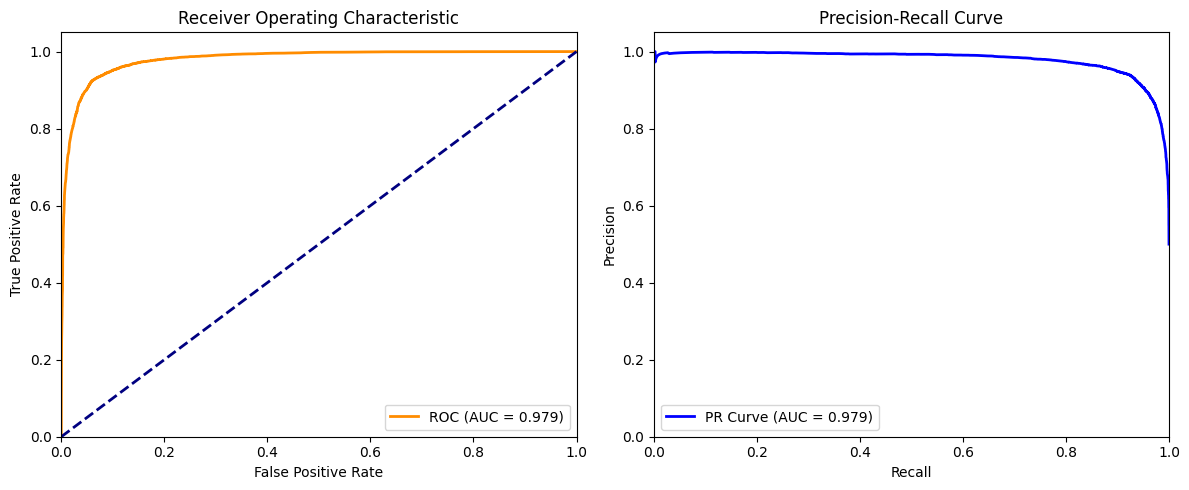

In [9]:


print("Оценка на тестовой выборке")
test_results = trainer.predict(tokenized_test)
test_preds = np.argmax(test_results.predictions, axis=-1)
test_labels = test_results.label_ids#извлечение правильных ответов
test_acc = accuracy_score(test_labels, test_preds)
print(f"Точность на тесте: {test_acc:.4f}")

test_probs = torch.softmax(torch.tensor(test_results.predictions), dim=-1)[:, 1].numpy()

fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = roc_auc_score(test_labels, test_probs)

precision, recall, _ = precision_recall_curve(test_labels, test_probs)
pr_auc = auc(recall, precision)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")

plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

In [ ]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model.eval()

test_texts = [
    "This movie was absolutely wonderful! The acting was great and the plot was exciting.",
    "Terrible film. I wasted two hours of my life. The story made no sense."
]

inputs = tokenizer(test_texts, padding=True, truncation=True, max_length=512, return_tensors="pt")

device = next(model.parameters()).device
inputs = {key: val.to(device) for key, val in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)
    predictions = torch.softmax(outputs.logits, dim=-1)

labels = ["Negative", "Positive"]

print("\nРЕЗУЛЬТАТЫ ПРОВЕРКИ")
for i, text in enumerate(test_texts):
    prob_neg = predictions[i][0].item()
    prob_pos = predictions[i][1].item()

    predicted_class_idx = torch.argmax(predictions[i]).item()
    predicted_label = labels[predicted_class_idx]

    print(f"\nТекст: \"{text}\"")
    print(f"Вероятность Negative: {prob_neg:.4f}")
    print(f"Вероятность Positive: {prob_pos:.4f}")
    print(f"Вердикт модели: {predicted_label}")
    print("-" * 30)


--- РЕЗУЛЬТАТЫ ПРОВЕРКИ ---

Текст: "This movie was absolutely wonderful! The acting was great and the plot was exciting."
Вероятность Negative: 0.0045
Вероятность Positive: 0.9955
Вердикт модели: Positive
------------------------------

Текст: "Terrible film. I wasted two hours of my life. The story made no sense."
Вероятность Negative: 0.9959
Вероятность Positive: 0.0041
Вердикт модели: Negative
------------------------------
